### Import of required Libraries

In [1]:
# --- Standard libraries ---
import json
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- IPython (for Jupyter display utilities) ---
from IPython.display import SVG, clear_output

# --- Plotly (interactive plotting) ---
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots  # optional, falls benötigt

# --- Scientific / statistical tools ---
from scipy import stats

# --- Scikit-learn: preprocessing, model selection, metrics, calibration ---
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder

# --- LightGBM ---
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from optuna.integration import lightgbm as lgb_optuna

# --- TensorFlow / Keras (for AROT model) ---
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.layers import Concatenate, Dense, Dropout, Flatten

# --- Domain-specific library: traffic data ---
from traffic.core import Traffic


c:\Users\hanv\Desktop\Master\EVA\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [73]:
pd.set_option("display.max_columns", None)

#### Import Data

In [74]:
final_table = pd.read_csv('Final_Table_V2.csv')

#### Create a Copy of Final Table to work with

In [75]:
data = final_table.copy()

##### Decrease the number of Airlines and replace those with not enough appearances with unknown + parking position

In [76]:
def replace_rare_icaos(group, threshold=50):
    # Count ICAO codes within the group
    counts = group['ICAO Code'].value_counts()
    rare_icaos = counts[counts < threshold].index
    # Replace rare ICAOs with e.g., "Rare_North" or "Rare_South"
    group['ICAO Code'] = group['ICAO Code'].apply(
        lambda x: f"Rare_{group.name}" if x in rare_icaos else x
    )
    return group

# Apply the function group-wise by Gate Region
data = data.groupby('Gate Region').apply(replace_rare_icaos).reset_index(drop=True)


C:\Users\hanv\AppData\Local\Temp\ipykernel_25604\921608701.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('Gate Region').apply(replace_rare_icaos).reset_index(drop=True)


##### Decrease the number of A/C Types and replace those with not enough appearances with unknown + parking position

In [77]:
def replace_rare_ac_types(group, threshold=50):
    # Count A/C Types within the group
    counts = group['A/C Type'].value_counts()
    rare_types = counts[counts < threshold].index
    # Replace rare A/C Types with e.g., "Rare_Heavy", "Rare_Light", etc.
    group['A/C Type'] = group['A/C Type'].apply(
        lambda x: f"Rare_{group.name}" if x in rare_types else x
    )
    return group

# Apply the function group-wise by ICAO Weight Turbulence Category
data = data.groupby('ICAO Weight Turbulence Category').apply(replace_rare_ac_types).reset_index(drop=True)


C:\Users\hanv\AppData\Local\Temp\ipykernel_25604\2761709303.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('ICAO Weight Turbulence Category').apply(replace_rare_ac_types).reset_index(drop=True)


#### Determine the Difference of the Entry Time between successive Arrivals

In [78]:
# Cleanly sort and reset integer index
data = data.sort_values(by="Time of Prediction", ignore_index=True)

# Parse datetime fields
data['Entry Time'] = pd.to_datetime(data['Entry Time'])
data['Exit Time']  = pd.to_datetime(data['Exit Time'])

# Time difference to the next entry time (in seconds)
data['Entry Time Difference (s)'] = (
    data['Entry Time'].shift(-1) - data['Entry Time']
).dt.total_seconds()


#### Determine Time Buffers

In [79]:
# Cleanly sort and reset integer index
data = data.sort_values(by="Time of Prediction", ignore_index=True)

# Time difference to the next entry time (in seconds)
data['Time Difference (s)'] = (
    data['Entry Time'].shift(-1) - data['Exit Time']
).dt.total_seconds()


In [80]:
data

,Flight ID,Entry Time,Exit Time,ICAO Code,A/C Type,ICAO Aircraft Type,Propulsion Type,Number of Engines,MALW [kg],ICAO Weight Turbulence Category,Gate Region,RET,ROT [s],Time of Prediction,Wind speed [kt],Wind direction [°],Visibility Category,Temperature [°C],Meteo idx,Precipitation [mm],Precipitation idx,Precipitation Timestamp,Hour sin,Hour cos,Minute sin,Minute cos,Day of week sin,Day of week cos,Month sin,Month cos,Year sin,Year cos,Day/Night,No Wind,Wind Variable,Wind direction sin,Wind direction cos,Headwind [kt],Crosswind [kt],Traffic Intensity RWY 10,Traffic Intensity RWY 14,Departure Traffic Intensity RWY 16,Arrival Traffic Intensity RWY 16,Traffic Intensity RWY 16,Departure Traffic Intensity RWY 28,Arrival Traffic Intensity RWY 28,Traffic Intensity RWY 28,Traffic Intensity RWY 32,Departure Traffic Intensity RWY 34,Arrival Traffic Intensity RWY 34,Traffic Intensity RWY 34,Airport Departure Traffic Intensity,Airport Arrival Traffic Intensity,Total Airport Traffic Intensity,Time Reserve [s],Number of preceding Traffic,Preceding Traffic ICAO Code,Preceding Traffic A/C Type,Preceding Traffic ICAO Aircraft Type,Preceding Traffic Propulsion Type,Preceding Traffic Number of Engines,Preceding Traffic MALW [kg],Preceding Traffic ICAO Weight Turbulence Category,Preceding Traffic Gate,Preceding Aircraft Geoaltitude,Preceding Aircraft Speed,Distance to Preceding Aircraft,Number of Successive Traffic,Successive Traffic ID,Successive Traffic A/C Type,Successive Traffic Geoaltitude,Successive Traffic Groundspeed,Successive Traffic Track,Successive Traffic Vertical Rate,Successive Traffic Distance,Successive Traffic Track sin,Successive Traffic Track cos,Successor Aligned,ROT Previous Flight [s],Average ROT Previous 5 Flight [s],Average ROT Previous Flight (Intensity) [s],ROT Previous Flight same A/C Type [s],Average ROT Previous 5 Flights same A/C Type [s],Average ROT Previous Flight same A/C Type (Intensity) [s],Average ROT Previous Flight same A/C Type Total [s],ROT Previous Flight same ICAO Weight Category [s],Average ROT Previous 5 Flights same ICAO Weight Category [s],Average ROT Previous Flight same ICAO Weight Category (Intensity) [s],Average ROT Previous Flight same ICAO Weight Category Total [s],Average ROT Total [s],groundspeed at prediction,geoaltitude at prediction,vertical_rate at prediction,distance at prediction,station,reference_timestamp,temp_2m,temp_5cm,temp_surface,temp_chill,rh_2m,dewpoint_2m,vapour_pressure,pressure_qfe,pressure_qnh,pressure_qff,geopot_850,geopot_700,gust_1s_ms,wind_vec_ms,wind_scalar_ms,wind_dir,foehn_idx,wind_scalar_kmh,gust_3s_ms,gust_1s_kmh,gust_3s_kmh,precip_10min,snow_depth,rad_global,rad_diffuse,rad_lw_in,rad_lw_out,rad_sw_reflect,sunshine_10min,new_wind_speed_kt,new_headwind_kt,new_crosswind_kt,H1,H2,H3,Entry Time Difference (s),Time Difference (s)
0,SIA346_291674,2024-03-01 06:23:00+00:00,2024-03-01 06:23:57+00:00,SIA,B77W,L2J,Jet,2.0,251290.0,Heavy,North,H1,57.0,2024-03-01 06:21:26+00:00,1.0,0.0,3,5.0,16.0,0.6,30.0,2024-03-01 06:00:00+00:00,1.0,0.5,0.904508,0.206107,0.283058,0.049516,1.0,0.5,0.999013,0.531395,Day,False,True,0.000000,0.00000,1.00,1.00,0,0,0,0,0,7,0,7,0,0,0,0,7,0,7,NaN,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1325.000000,0.0,13.752771,0.0,NaN,NaN,16000.0,417.0,317.231857,0.0,19.097551,0.000000,0.000000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.0,2950.0,-896.0,4.003528,KLO,2024-03-01 06:20:00+00:00,5.1,4.4,4.6,5.1,97.1,4.7,8.5,959.0,1009.2,1010.3,NaN,NaN,1.5,1.1,1.1,106.0,NaN,4.0,1.5,5.4,5.4,0.4,0.0,2,1.0,336,NaN,NaN,0,2.159827,1.85,-1.12,0,0,0,582.0,525.0
1,ETH736_1162,2024-03-01 06:32:42+00:00,2024-03-01 06:33:36+00:00,ETH,A359,L2J,Jet,2.0,207000.0,Heavy,South,H1,54.0,2024-03-01 06:31:12+00:00,1.0,0.0,3,5.0,16.0,0.6,30.0,2024-03-01 06:00:00+00:00,1.0,0.5,0.447736,0.002739,0.283058,0.049516,1.0,0.5,0.999013,0.531395,Day,False,True,0.000000,0.00000,1.00,1.00,0,1,0,0,0,9,0,9,0,0,0,0,9,1,10,525.0,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1325.000000,0.0,13.752771,0.0,NaN,

#### Extract only Data which vacated the Runway via an valid Exit Taxiway

In [81]:
data = data[(data['RET'] == 'H1') | (data['RET'] == 'H2') | (data['RET'] == 'H3')] # H3 included for Time Buffer Plot. Will be removed in another step

#### Define a lower threshold of 39 secondes to remove faulty data

In [82]:
data = data[data['ROT [s]'] >=39]

In [83]:
data = data[data['Entry Time Difference (s)'] > 0]

#### Set Categorical Types

In [84]:
data['A/C Type'] = data['A/C Type'].astype('category')
data['ICAO Code'] = data['ICAO Code'].astype('category')
data['ICAO Weight Turbulence Category'] = data['ICAO Weight Turbulence Category'].astype('category')
data['Propulsion Type'] = data['Propulsion Type'].astype('category')
data['Day/Night'] = data['Day/Night'].astype('category')
data['No Wind'] = data['No Wind'].astype('category')
data['Wind Variable'] = data['Wind Variable'].astype('category')
data['Gate Region'] = data['Gate Region'].astype('category')

In [85]:
# List of all flight IDs to be removed
invalid_ids = [
    # H1 - Long ROTs
    "SAS841_74600", "AEA91MP_5645", "SWR4GV_272636", "EDW675Z_191415",
    "SWR504W_144961", "SPEMC_64994", "SWR9GW_88322", "SWR2EP_134507",
    "SWR296W_280795", "SWR1TC_125514", "SWR969_80375", "DLH8WN_29304",
    # H1 - Short ROTs
    "SWR4CQ_236343", "DISAG_33952", "SWR9LZ_128323", "EWG95AW_269167",
    "SWR6MW_223600", "SWR3BY_105353", "SWR339H_132594",
    # H1 - Other observations
    "AUA55C_45096", "SXS7SL_251961", "SKV444_46316", "EJU5189_45326",
    "LDX20C_46560", "EWG59L_261077", "VJT518_261031", "EJU96HY_45377",
    "OEFXY_45632", "OEFXY_45636",
    # H2 - Long ROTs
    "SWR589X_197642", "KAL917_289693", "SWR262C_114944", "AUA5U_46704",
    "SWR2HE_111023", "SWR2DG_96864", "DCSEB_32456", "EWG64R_20879",
    "SWR71Y_279675", "SWR457_141457", "SWR539L_276851", "SWR4MY_85273",
    "SWR438A_87128", "SWR5KP_133206",
    # H2 - Short ROTs
    "SWR4GV_201277", "DLH8CM_16669", "SXS9UC_253202", "SWR30M_194526",
    "SWR63D_99758", "SWR296W_285509", "SWR5GZ_115709", "EDW215P_195137",
    "SWR2DG_196962", "SWR2121_121074", "SWR98X_84057", "SWR8WK_160440",
    "SWR5CL_121762", "SWR189_202667", "SWR9LZ_126613", "SWR622P_79915",
    # H3 - Short ROTs
    "LMJ920F_67939",
    # H3 - Other
    "RGA01_245094",
]

# Filter out invalid flight IDs
data = data[~data["Flight ID"].isin(invalid_ids)].copy()

# Filter out unwanted aircraft types
invalid_ac_types = ["SF25", "PA18", "PA31", "PA34", "TB20", "C207", "DA40"]
data = data[~data['A/C Type'].isin(invalid_ac_types)]

# Create a copy for plotting
data_buffer_plot = data.copy()


##### Remove H3 from dataset

In [86]:
data = data[(data['RET'] == 'H1') | (data['RET'] == 'H2')]

#### Remove Flights which are considered as irrelevant due to their Time Difference

In [87]:
heavy = data['ICAO Weight Turbulence Category'].isin(['Heavy', 'Super', 'H', 'J'])

mask = (heavy  & (data['Entry Time Difference (s)'] <= 180)) | \
       (~heavy & (data['Entry Time Difference (s)'] <= 120))

data = data[mask]

#### Define X_ret for RET prediction

In [88]:
X_ret = data[[
    'ICAO Code',
    'MALW [kg]',
    'Gate Region',
    'new_headwind_kt',
    'new_crosswind_kt',
    'Visibility Category',
    'temp_2m',
    'pressure_qnh',
    'precip_10min',
    'Month sin',
    'Month cos',
    'Day of week sin',
    'Day of week cos',
    'groundspeed at prediction',
]]

#### Filter categorical Columns in X_ret

In [89]:
categorical_columns = [
    'ICAO Code',
    'ICAO Weight Turbulence Category',
    'Gate Region',
]


#### Identify Categorical Feature Indices

In [90]:
categorical_columns_in_X = [col for col in categorical_columns if col in X_ret.columns]
categorical_feature_indices = [X_ret.columns.get_loc(col) for col in categorical_columns_in_X]

#### Remove NaN from the Dataset (only based on X_ret)

In [91]:
X_ret = X_ret.dropna()

#### Remove special characters from the column names

In [92]:
X_ret_columns_names = X_ret.columns
X_ret.columns = X_ret.columns.str.replace(r"[\[\]<>]", "", regex=True)

#### Define Target

In [93]:
y_ret = data.loc[X_ret.index, ['RET']]

#### Encode Target

In [94]:
# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y_ret)

c:\Users\hanv\Desktop\Master\EVA\Code\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


#### Split Set in a Set for RET Predcition Model and in a Set for ROT Prediction Model (ROT Set is the Test set of the RET Set)

In [95]:
X_ret, X_rot, y_ret, y_rot = train_test_split(
    X_ret, y_encoded, test_size=0.5, random_state=42
)

#### Define Train and Validation Set of the RET Set

In [96]:
X_ret_train, X_ret_val, y_ret_train, y_ret_val = train_test_split(
    X_ret, y_ret, test_size=0.2, random_state=42
)

#### Encode Categorical Features

In [97]:
ordinal_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

In [98]:
X_ret_train_encoded = X_ret_train.copy()
X_ret_val_encoded = X_ret_val.copy()
X_ret_rot_encoded = X_rot.copy()

# Encode only the categorical columns
X_ret_train_encoded[categorical_columns_in_X] = ordinal_encoder.fit_transform(X_ret_train[categorical_columns_in_X])
X_ret_val_encoded[categorical_columns_in_X] = ordinal_encoder.transform(X_ret_val[categorical_columns_in_X])
X_ret_rot_encoded[categorical_columns_in_X] = ordinal_encoder.transform(X_rot[categorical_columns_in_X])

X_ret_resampled, y_ret_resampled = X_ret_train_encoded, y_ret_train # Originaly we applied SMOTENC which was later removed

#### Define the RET Model and Optuna Hyperparameter Optimization

In [99]:
# --- Set seeds ---
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)

# --- Training and validation data ---
train_data = lgb.Dataset(X_ret_resampled, label=y_ret_resampled)
valid_data = lgb.Dataset(X_ret_val_encoded, label=y_ret_val)

# --- Base parameters ---
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "feature_pre_filter": False,
    "seed": 42,
    "feature_fraction_seed": 42,
    "bagging_seed": 42,
    "data_random_seed": 42,
    "deterministic": True,
    "num_threads": 1,
}

# --- Optuna tuning (no k-fold) ---
tuner = lgb_optuna.LightGBMTuner(
    params=params,
    train_set=train_data,
    valid_sets=[valid_data],
    valid_names=["validation"],
    num_boost_round=2000,
    callbacks=[early_stopping(stopping_rounds=50)],
    optuna_seed=42,
)

tuner.run()

# --- Best parameters & score ---
best_params = tuner.best_params
best_score = tuner.best_score
best_booster = tuner.get_best_booster()
best_iter = best_booster.best_iteration

print("\nBest Parameters:")
for k, v in best_params.items(): print(f"  {k}: {v}")
print(f"\nBest Validation Logloss: {best_score:.5f}")
print(f"Best Iteration: {best_iter}")

# --- Final sklearn model (fit) with fixed random state ---
best_params.update({
    "n_estimators": best_iter,
    "objective": "binary",
    "boosting_type": "gbdt",
    "verbosity": -1,
    "random_state": 42,
    "num_threads": 1,
})

lgbm_model = lgb.LGBMClassifier(**best_params)

lgbm_model.fit(
    X_ret_resampled, y_ret_resampled,
    eval_set=[(X_ret_val_encoded, y_ret_val)],
    eval_metric=["logloss", "auc", "aucpr"],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)],
)

# --- Evaluation ---
y_val_pred_proba = lgbm_model.predict_proba(X_ret_val_encoded)[:, 1]
print("\nValidation Logloss:", log_loss(y_ret_val, y_val_pred_proba))
print("Validation AUC:", roc_auc_score(y_ret_val, y_val_pred_proba))


[I 2026-03-22 17:15:52,186] A new study created in memory with name: no-name-af80f2e9-0f2b-40fa-98e5-45330818df33


feature_fraction, val_score: inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.456168:  14%|#4        | 1/7 [00:00<00:03,  1.86it/s]

Early stopping, best iteration is:
[222]	validation's binary_logloss: 0.456168
Training until validation scores don't improve for 50 rounds


...

min_child_samples, val_score: 0.452890:  80%|########  | 4/5 [00:02<00:00,  1.71it/s]

Early stopping, best iteration is:
[100]	validation's binary_logloss: 0.455561
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.452890: 100%|##########| 5/5 [00:03<00:00,  1.58it/s]

Early stopping, best iteration is:
[151]	validation's binary_logloss: 0.455758

Best Parameters:
  objective: binary
  metric: binary_logloss
  verbosity: -1
  boosting_type: gbdt
  feature_pre_filter: False
  seed: 42
  feature_fraction_seed: 42
  bagging_seed: 42
  data_random_seed: 42
  deterministic: True
  num_threads: 1
  lambda_l1: 0.014607715801349994
  lambda_l2: 2.0750022643683693e-06
  num_leaves: 45
  feature_fraction: 0.9799999999999999
  bagging_fraction: 1.0
  bagging_freq: 0
  min_child_samples: 20

Best Validation Logloss: 0.45289
Best Iteration: 177
Training until validation scores don't improve for 50 rounds


[50]	valid_0's auc: 0.797168	valid_0's binary_logloss: 0.462158
[100]	valid_0's auc: 0.80411	valid_0's binary_logloss: 0.456362
[150]	valid_0's auc: 0.806915	valid_0's binary_logloss: 0.454646
Did not meet early stopping. Best iteration is:
[177]	valid_0's auc: 0.809566	valid_0's binary_logloss: 0.45289

Validation Logloss: 0.4528903961322931
Validation AUC: 0.8095659972452458


#### Train Model

#### Evaluate Training

In [100]:
# Predict class probabilities for the training set
probs_ret_train = lgbm_model.predict_proba(X_ret_resampled)  # Shape: (n_samples, n_classes)

# Convert probabilities to class predictions (hard labels)
y_ret_train_pred = np.argmax(probs_ret_train, axis=1)

# Inverse transform to original labels if LabelEncoder was used
y_ret_train_pred_labels = le.inverse_transform(y_ret_train_pred)
y_ret_train_labels = le.inverse_transform(y_ret_resampled)

# --- Classification Metrics ---
print("Training Accuracy (LightGBM):", accuracy_score(y_ret_resampled, y_ret_train_pred))
print("Training Log Loss:", log_loss(y_ret_resampled, probs_ret_train))
print("\nClassification Report (LightGBM):")
print(classification_report(y_ret_resampled, y_ret_train_pred, target_names=le.classes_))

# --- Calibration Curve (per class) ---
traces = []
for i, class_label in enumerate(le.classes_):
    y_true_bin = (y_ret_resampled == i).astype(int)
    prob_true, prob_pred = calibration_curve(y_true_bin, probs_ret_train[:, i], n_bins=10)
    traces.append(go.Scatter(
        x=prob_pred,
        y=prob_true,
        mode='lines+markers',
        name=f'Class: {class_label}'
    ))

# Diagonal reference line
traces.append(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(dash='dash', color='gray'),
    showlegend=False
))

fig_cal = go.Figure(data=traces)
fig_cal.update_layout(
    title="Calibration Curve – Training Data",
    xaxis_title="Predicted Probability",
    yaxis_title="Observed Frequency",
    width=600,
    height=500
)
fig_cal.show()

# --- Classification Report (Plotly Table) ---
report = classification_report(y_ret_resampled, y_ret_train_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T.reset_index().rename(columns={'index': 'Class'})
report_df = report_df.round(3)


Training Accuracy (LightGBM): 0.8609625668449198
Training Log Loss: 0.3238323729140639

Classification Report (LightGBM):
              precision    recall  f1-score   support

          H1       0.84      0.98      0.91     15563
          H2       0.94      0.58      0.71      6690

    accuracy                           0.86     22253
   macro avg       0.89      0.78      0.81     22253
weighted avg       0.87      0.86      0.85     22253



#### Evaluate Validation

In [101]:
# Predict class probabilities for the validation set
probs_ret_val = lgbm_model.predict_proba(X_ret_val_encoded)  # Shape: (n_samples, n_classes)

# Convert probabilities to class predictions
y_ret_val_pred = np.argmax(probs_ret_val, axis=1)

# Inverse transform to original labels if LabelEncoder was used
y_ret_val_pred_labels = le.inverse_transform(y_ret_val_pred)
y_ret_val_labels = le.inverse_transform(y_ret_val)

# --- Classification Metrics ---
print("Validation Accuracy (LightGBM):", accuracy_score(y_ret_val, y_ret_val_pred))
print("Validation Log Loss:", log_loss(y_ret_val, probs_ret_val))
print("\nClassification Report (LightGBM):")
print(classification_report(y_ret_val, y_ret_val_pred, target_names=le.classes_))


# --- Predict class probabilities and labels ---
probs_ret_val = lgbm_model.predict_proba(X_ret_val_encoded)
y_ret_val_pred = np.argmax(probs_ret_val, axis=1)
y_ret_val_pred_labels = le.inverse_transform(y_ret_val_pred)
y_ret_val_labels = le.inverse_transform(y_ret_val)

# --- Calibration Curve per class ---
traces = []
for i, class_label in enumerate(le.classes_):
    y_true_bin = (y_ret_val == i).astype(int)
    prob_true, prob_pred = calibration_curve(y_true_bin, probs_ret_val[:, i], n_bins=10)
    traces.append(go.Scatter(
        x=prob_pred,
        y=prob_true,
        mode='lines+markers',
        name=f'Class: {class_label}'
    ))

traces.append(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(dash='dash', color='gray'),
    showlegend=False
))

fig_cal = go.Figure(data=traces)
fig_cal.update_layout(
    title="Calibration Curve – Validation Data",
    xaxis_title="Predicted Probability",
    yaxis_title="Observed Frequency",
    width=600,
    height=500
)
fig_cal.show()


Validation Accuracy (LightGBM): 0.789000718907261
Validation Log Loss: 0.4528903961322931

Classification Report (LightGBM):
              precision    recall  f1-score   support

          H1       0.79      0.95      0.86      3907
          H2       0.78      0.41      0.54      1657

    accuracy                           0.79      5564
   macro avg       0.78      0.68      0.70      5564
weighted avg       0.79      0.79      0.77      5564



#### ROT Set

In [102]:
# Predict class probabilities for the test set
probs_ret_rot = lgbm_model.predict_proba(X_ret_rot_encoded)  # Shape: (n_samples, n_classes)

# Convert probabilities to class predictions
y_ret_rot_pred = np.argmax(probs_ret_rot, axis=1)

# Inverse transform to original labels if LabelEncoder was used
y_ret_rot_pred_labels = le.inverse_transform(y_ret_rot_pred)
y_ret_rot_labels = le.inverse_transform(y_rot)

# --- Classification Metrics ---
print("Test Accuracy (LightGBM):", accuracy_score(y_rot, y_ret_rot_pred))
print("Test Log Loss:", log_loss(y_rot, probs_ret_rot))
print("\nClassification Report (LightGBM):")
print(classification_report(y_rot, y_ret_rot_pred, target_names=le.classes_))

# --- Predict class probabilities and labels ---
probs_ret_rot = lgbm_model.predict_proba(X_ret_rot_encoded)
y_ret_rot_pred = np.argmax(probs_ret_rot, axis=1)
y_ret_rot_pred_labels = le.inverse_transform(y_ret_rot_pred)
y_ret_rot_labels = le.inverse_transform(y_rot)

# --- Calibration Curve per class ---
traces = []
for i, class_label in enumerate(le.classes_):
    y_true_bin = (y_rot == i).astype(int)
    prob_true, prob_pred = calibration_curve(y_true_bin, probs_ret_rot[:, i], n_bins=10)
    traces.append(go.Scatter(
        x=prob_pred,
        y=prob_true,
        mode='lines+markers',
        name=f'Class: {class_label}'
    ))

traces.append(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(dash='dash', color='gray'),
    showlegend=False
))

fig_cal = go.Figure(data=traces)
fig_cal.update_layout(
    title="Calibration Curve – Test Data",
    xaxis_title="Predicted Probability",
    yaxis_title="Observed Frequency",
    width=600,
    height=500
)
fig_cal.show()

Test Accuracy (LightGBM): 0.7936228341361709
Test Log Loss: 0.44340115380037404

Classification Report (LightGBM):
              precision    recall  f1-score   support

          H1       0.80      0.95      0.87     19649
          H2       0.77      0.43      0.55      8169

    accuracy                           0.79     27818
   macro avg       0.78      0.69      0.71     27818
weighted avg       0.79      0.79      0.77     27818



#### Calibration Curve Plot for Paper

In [103]:
# Create output directory if it does not exist
output_dir = 'Plots'
os.makedirs(output_dir, exist_ok=True)

# Define color and marker sets
colors = ['blue', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta', 'olive', 'grey', 'black']
symbols = ['circle', 'square', 'triangle-up', 'diamond', 'cross', 'x', 'triangle-down',
           'triangle-left', 'triangle-right', 'star']

# Compute calibration curves for each class
traces = []
for i, class_label in enumerate(le.classes_):
    y_true_bin = (y_rot == i).astype(int)
    prob_true, prob_pred = calibration_curve(y_true_bin, probs_ret_rot[:, i], n_bins=10)

    traces.append(go.Scatter(
        x=prob_pred,
        y=prob_true,
        mode='lines+markers',
        name=f'Class: {class_label}',
        line=dict(color=colors[i % len(colors)]),
        marker=dict(
            size=10,
            symbol=symbols[i % len(symbols)],
            color=colors[i % len(colors)],
            line=dict(width=1, color='black'),
            opacity=0.7
        )
    ))

# Add perfect calibration reference line
reference_line = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    line=dict(color='red', dash='dash', width=2),
    name='Perfect Calibration'
)

# Define layout
layout = go.Layout(
    width=800,
    height=500,
    xaxis=dict(
        title='Predicted Probability',
        title_font=dict(size=22),
        tickfont=dict(size=18),
        range=[0, 1]
    ),
    yaxis=dict(
        title='Observed Frequency',
        title_font=dict(size=22),
        tickfont=dict(size=18),
        range=[0, 1]
    ),
    showlegend=True,
    legend=dict(x=0.01, y=0.99, font=dict(size=14)),
    margin=dict(l=50, r=50, t=40, b=50)
)

# Create and save figure
fig_cal = go.Figure(data=traces + [reference_line], layout=layout)
fig_cal.write_image(os.path.join(output_dir, 'calibration_curve_test.pdf'), scale=5)

# Display interactive plot
fig_cal.show()


#### Save Predicted Probabilities to data_rot

In [104]:
data_rot = data.loc[X_rot.index]

In [105]:
# Store predicted probabilities in a DataFrame with the same index as X_rot
probs_df = pd.DataFrame(
    probs_ret_rot,
    columns=[f'prob_{cls}' for cls in le.classes_],
    index=X_rot.index
)

# Add predicted and true RET labels for further analysis (optional)
probs_df["RET_pred"] = y_ret_rot_pred_labels
probs_df["RET_true"] = le.inverse_transform(y_rot)

# Combine input features with probability and label information
X_rot_with_probs = pd.concat([X_rot, probs_df], axis=1)

In [106]:
# Combine: all features from X_rot, predicted probabilities, and target values
data_rot = pd.concat([data_rot, probs_df], axis=1)

#### Sort AROT dataset regarding Time of Prediction

In [107]:
data_rot = data_rot.sort_values('Time of Prediction')

#### Import and prepare required Trajectories

In [108]:
trajs_data = pd.read_parquet('Trajectory_Snippet.parquet')
trajs_data = trajs_data.query('groundspeed <= 240')
trajs_data = trajs_data.query('geoaltitude <= 5000')
trajs_data = Traffic(trajs_data)
trajs_data = trajs_data[data_rot['Flight ID'].unique()]

#### Remove Trajectories from the set which don't have the required length

In [109]:
def filter_flights(flight):
    if len(flight.data) == 10:
        return flight

In [110]:
trajs_data = trajs_data.iterate_lazy().pipe(filter_flights).eval(max_workers=1, desc='Processing')
relevant_flight_ids = trajs_data.flight_ids
data_rot = data_rot[data_rot['Flight ID'].isin(relevant_flight_ids)]
data_rot = data_rot.sort_values('Time of Prediction')

In [111]:
data_rot

,Flight ID,Entry Time,Exit Time,ICAO Code,A/C Type,ICAO Aircraft Type,Propulsion Type,Number of Engines,MALW [kg],ICAO Weight Turbulence Category,Gate Region,RET,ROT [s],Time of Prediction,Wind speed [kt],Wind direction [°],Visibility Category,Temperature [°C],Meteo idx,Precipitation [mm],Precipitation idx,Precipitation Timestamp,Hour sin,Hour cos,Minute sin,Minute cos,Day of week sin,Day of week cos,Month sin,Month cos,Year sin,Year cos,Day/Night,No Wind,Wind Variable,Wind direction sin,Wind direction cos,Headwind [kt],Crosswind [kt],Traffic Intensity RWY 10,Traffic Intensity RWY 14,Departure Traffic Intensity RWY 16,Arrival Traffic Intensity RWY 16,Traffic Intensity RWY 16,Departure Traffic Intensity RWY 28,Arrival Traffic Intensity RWY 28,Traffic Intensity RWY 28,Traffic Intensity RWY 32,Departure Traffic Intensity RWY 34,Arrival Traffic Intensity RWY 34,Traffic Intensity RWY 34,Airport Departure Traffic Intensity,Airport Arrival Traffic Intensity,Total Airport Traffic Intensity,Time Reserve [s],Number of preceding Traffic,Preceding Traffic ICAO Code,Preceding Traffic A/C Type,Preceding Traffic ICAO Aircraft Type,Preceding Traffic Propulsion Type,Preceding Traffic Number of Engines,Preceding Traffic MALW [kg],Preceding Traffic ICAO Weight Turbulence Category,Preceding Traffic Gate,Preceding Aircraft Geoaltitude,Preceding Aircraft Speed,Distance to Preceding Aircraft,Number of Successive Traffic,Successive Traffic ID,Successive Traffic A/C Type,Successive Traffic Geoaltitude,Successive Traffic Groundspeed,Successive Traffic Track,Successive Traffic Vertical Rate,Successive Traffic Distance,Successive Traffic Track sin,Successive Traffic Track cos,Successor Aligned,ROT Previous Flight [s],Average ROT Previous 5 Flight [s],Average ROT Previous Flight (Intensity) [s],ROT Previous Flight same A/C Type [s],Average ROT Previous 5 Flights same A/C Type [s],Average ROT Previous Flight same A/C Type (Intensity) [s],Average ROT Previous Flight same A/C Type Total [s],ROT Previous Flight same ICAO Weight Category [s],Average ROT Previous 5 Flights same ICAO Weight Category [s],Average ROT Previous Flight same ICAO Weight Category (Intensity) [s],Average ROT Previous Flight same ICAO Weight Category Total [s],Average ROT Total [s],groundspeed at prediction,geoaltitude at prediction,vertical_rate at prediction,distance at prediction,station,reference_timestamp,temp_2m,temp_5cm,temp_surface,temp_chill,rh_2m,dewpoint_2m,vapour_pressure,pressure_qfe,pressure_qnh,pressure_qff,geopot_850,geopot_700,gust_1s_ms,wind_vec_ms,wind_scalar_ms,wind_dir,foehn_idx,wind_scalar_kmh,gust_3s_ms,gust_1s_kmh,gust_3s_kmh,precip_10min,snow_depth,rad_global,rad_diffuse,rad_lw_in,rad_lw_out,rad_sw_reflect,sunshine_10min,new_wind_speed_kt,new_headwind_kt,new_crosswind_kt,H1,H2,H3,Entry Time Difference (s),Time Difference (s),prob_H1,prob_H2,RET_pred,RET_true
2,UAL3_297665,2024-03-01 06:38:42+00:00,2024-03-01 06:39:42+00:00,UAL,B763,L2J,Jet,2.0,145149.0,Heavy,North,H1,60.0,2024-03-01 06:37:04+00:00,1.0,0.0,3,5.0,16.0,0.6,30.0,2024-03-01 06:00:00+00:00,1.000000,0.50000,0.165435,0.128428,0.283058,0.049516,1.0,0.5,0.999013,0.531395,Day,False,True,0.000000,0.000000,1.00,1.00,0,2,0,0,0,10,0,10,0,0,0,0,10,2,12,306.0,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1325.000000,0.0,13.752771,2.0,BEL1LX_54353,A319,5125.0,217.0,104.931417,-1280.0,7.481023,0.000000,0.000000,False,54.0,55.5,55.500000,54.0,55.500000,55.500000,55.500000,54.0,55.5,55.500000,55.500000,55.500000,180.0,2950.0,-1024.0,4.003528,KLO,2024-03-01 06:30:00+00:00,5.4,4.6,4.6,3.9,95.8,4.8,8.6,959.1,1009.3,1010.3,NaN,NaN,2.3,1.9,1.9,111.0,NaN,6.8,2.3,8.3,8.3,0.3,0.0,3,2.0,336,NaN,NaN,0,3.671706,3.29,-1.62,2,0,0,156.0,96.0,0.455901,0.544099,H2,H1
3,BEL1LX_54353,2024-03-01 06:41:18+00:00,2024-03-01 06:42:20+00:00,BEL,A319,L2J,Jet,2.0,61000.0,Medium,South,H1,62.0,2024-03-01 06:39:21+00:00,1.0,0.0,3,5.0,16.0,0.6,30.0,2024-03-01 06:00:00+00:00,1.000000,0.50000,0.095492,0.206107,0.283058,0.049516,1.0,0.5,0.999013,0.531395,Day,Fa

#### Define X_static (time-independent) with snippet features at the prediction point

In [112]:
X_static = data_rot[[
    'Flight ID', # Will be removed in a later step
    'A/C Type',
    'ICAO Code',
    'new_headwind_kt',
    'new_crosswind_kt',
    'temp_2m',
    'precip_10min',
    'prob_H1',
    'prob_H2',
    'Day of week sin',
    'Day of week cos',
    'Month sin',
    'Month cos',
    'groundspeed at prediction',
    'geoaltitude at prediction',
    'vertical_rate at prediction',
    'ROT [s]'   # Target! Will be removed in a later step
]]


##### Get rid of features with NaN

In [113]:
X_static = X_static.dropna()
req_flight_ids = X_static['Flight ID'].unique()

trajs_relevant_data = trajs_data[req_flight_ids]
trajs_relevant_data = trajs_relevant_data.data
trajs_relevant_data = trajs_relevant_data.sort_values(['timestamp', 'flight_id'])

#### Define X_time (time-dependent) (will not be used, just to assure that we end up with the same sets)

In [114]:
X_time = trajs_relevant_data[['groundspeed', 'geoaltitude', 'vertical_rate']]

##### One Hot Encoding of categorical features

In [115]:
X_static = pd.get_dummies(X_static, columns=['A/C Type'])
X_static = pd.get_dummies(X_static, columns=['ICAO Code'])

#### Save Feature Names

In [116]:
feature_names_static = X_static.columns.tolist()

### Define Target (y)

In [117]:
y = X_static['ROT [s]']

#### Remove Target and Flight ID from X_static

In [118]:
X_static = X_static.drop(columns=['ROT [s]'])
X_static = X_static.drop(columns=['Flight ID'])

#### Change structure of X_time to a processable structure

In [119]:
# Convert X_time to a NumPy array
X_time = np.array(X_time)

n_timepoints = 10
n_samples = X_static.shape[0]

# Safety check: truncate if there are too many rows
X_time = X_time[:n_samples * n_timepoints]

# Reshape to 3D array: (samples, timepoints, features)
X_time_reshaped = X_time.reshape(n_samples, n_timepoints, -1)

#### Split data in train, validation and test set

In [120]:
X_time_train, X_time_temp, X_static_train, X_static_temp, y_train, y_temp = train_test_split(
    X_time_reshaped, X_static, y, test_size=0.3, random_state=42
)

X_time_val, X_time_test, X_static_val, X_static_test, y_val, y_test = train_test_split(
    X_time_temp, X_static_temp, y_temp, test_size=0.5, random_state=42
)


In [121]:
X_static_test

,new_headwind_kt,new_crosswind_kt,temp_2m,precip_10min,prob_H1,prob_H2,Day of week sin,Day of week cos,Month sin,Month cos,groundspeed at prediction,geoaltitude at prediction,vertical_rate at prediction,A/C Type_A20N,A/C Type_A21N,A/C Type_A319,A/C Type_A320,A/C Type_A321,A/C Type_A332,A/C Type_A333,A/C Type_A343,A/C Type_A359,A/C Type_A35K,A/C Type_A388,A/C Type_B38M,A/C Type_B737,A/C Type_B738,A/C Type_B739,A/C Type_B752,A/C Type_B763,A/C Type_B764,A/C Type_B772,A/C Type_B77L,A/C Type_B77W,A/C Type_B788,A/C Type_B789,A/C Type_B78X,A/C Type_BCS1,A/C Type_BCS3,A/C Type_BE20,A/C Type_C25A,A/C Type_C25B,A/C Type_C25C,A/C Type_C25M,A/C Type_C510,A/C Type_C525,A/C Type_C56X,A/C Type_C680,A/C Type_C68A,A/C Type_CL30,A/C Type_CL35,A/C Type_CL60,A/C Type_CRJ2,A/C Type_CRJ9,A/C Type_DA42,A/C Type_DH8D,A/C Type_E190,A/C Type_E195,A/C Type_E290,A/C Type_E295,A/C Type_E35L,A/C Type_E50P,A/C Type_E550,A/C Type_E55P,A/C Type_E75L,A/C Type_F2TH,A/C Type_F900,A/C Type_FA7X,A/C Type_FA8X,A/C Type_GA5C,A/C Type_GL5T,A/C Type_GL7T,A/C Type_GLEX,A/C Type_GLF4,A/C Type_GLF5,A/C Type_GLF6,A/C Type_H25B,A/C Type_PC12,A/C Type_PC24,A/C Type_PRM1,A/C Type_Rare_Heavy,A/C Type_Rare_Light,A/C Type_Rare_Light,A/C Type_Rare_Light/Medium,A/C Type_Rare_Medium,A/C Type_SF50,A/C Type_SR22,ICAO Code_AAL,ICAO Code_ACA,ICAO Code_AEA,ICAO Code_AEE,ICAO Code_AFR,ICAO Code_AIC,ICAO Code_AOJ,ICAO Code_ASL,ICAO Code_AUA,ICAO Code_AZE,ICAO Code_BAW,ICAO Code_BEL,ICAO Code_BOM,ICAO Code_BTI,ICAO Code_CAI,ICAO Code_CAZ,ICAO Code_CFE,ICAO Code_CFG,ICAO Code_CPA,ICAO Code_CTN,ICAO Code_DAL,ICAO Code_DLH,ICAO Code_DWW,ICAO Code_EDW,ICAO Code_EIN,ICAO Code_EJU,ICAO Code_ELY,ICAO Code_ETD,ICAO Code_ETH,ICAO Code_EWG,ICAO Code_EZY,ICAO Code_FIN,ICAO Code_FJO,ICAO Code_FSE,ICAO Code_GAC,ICAO Code_GSW,ICAO Code_HBF,ICAO Code_HBJ,ICAO Code_HBK,ICAO Code_HBL,ICAO Code_HBV,ICAO Code_HUE,ICAO Code_IBE,ICAO Code_ICE,ICAO Code_ITY,ICAO Code_JFA,ICAO Code_JPV,ICAO Code_KAL,ICAO Code_KLM,ICAO Code_KMM,ICAO Code_LOT,ICAO Code_LZB,ICAO Code_MCK,ICAO Code_MNE,ICAO Code_MSC,ICAO Code_MSR,ICAO Code_NJE,ICAO Code_OAW,ICAO Code_OMA,ICAO Code_PGT,ICAO Code_PJV,ICAO Code_PJZ,ICAO Code_PTN,ICAO Code_QTR,ICAO Code_Rare_East,ICAO Code_Rare_North,ICAO Code_Rare_South,ICAO Code_Rare_Unknown,ICAO Code_Rare_West,ICAO Code_SAS,ICAO Code_SAZ,ICAO Code_SIA,ICAO Code_SVA,ICAO Code_SWR,ICAO Code_SXS,ICAO Code_TAP,ICAO Code_THA,ICAO Code_THY,ICAO Code_TKJ,ICAO Code_UAE,ICAO Code_UAL,ICAO Code_VJH,ICAO Code_VJT,ICAO Code_VLG,ICAO Code_XRO
36816,0.72,-7.15,31.5,0.0,0.933168,0.066832,0.109084,0.811745,0.066987,0.250000,156.0,2950.0,-960.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
61900,-3.06,9.00,5.3,0.0,0.708211,0.291789,0.109084,0.811745,0.250000,0.933013,168.0,2925.0,-1152.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

In [122]:
index = X_static_test.index

#### Scale data without data breach

In [123]:
# --- Scale only selected continuous static features ---
columns_to_scale = [
    'new_headwind_kt',
    'new_crosswind_kt',
    'temp_2m',
    'precip_10min',
]

# Create a separate scaler for static features
scaler_static = MinMaxScaler(feature_range=(0, 1))

# Copy static feature sets to preserve original data
X_static_train_scaled = X_static_train.copy()
X_static_val_scaled   = X_static_val.copy()
X_static_test_scaled  = X_static_test.copy()

# Apply scaling to selected columns
X_static_train_scaled[columns_to_scale] = scaler_static.fit_transform(X_static_train[columns_to_scale])
X_static_val_scaled[columns_to_scale]   = scaler_static.transform(X_static_val[columns_to_scale])
X_static_test_scaled[columns_to_scale]  = scaler_static.transform(X_static_test[columns_to_scale])

# Overwrite the original variables with the scaled versions
X_static_train = X_static_train_scaled
X_static_val   = X_static_val_scaled
X_static_test  = X_static_test_scaled

# --- Scale all time-dependent features ---
# Input shape: (samples, timesteps, features)
n_samples, timesteps, n_features = X_time_train.shape

# Flatten 3D arrays to 2D for scaling
X_time_train_flat = X_time_train.reshape(-1, n_features)
X_time_val_flat   = X_time_val.reshape(-1, n_features)
X_time_test_flat  = X_time_test.reshape(-1, n_features)

# Create a separate scaler for time-dependent features
scaler_time = MinMaxScaler(feature_range=(0, 1))

# Fit and transform training data; transform validation and test data
X_time_train_flat = scaler_time.fit_transform(X_time_train_flat)
X_time_val_flat   = scaler_time.transform(X_time_val_flat)
X_time_test_flat  = scaler_time.transform(X_time_test_flat)

# Reshape back to original 3D format
X_time_train = X_time_train_flat.reshape(n_samples, timesteps, n_features)
X_time_val   = X_time_val_flat.reshape(X_time_val.shape[0], timesteps, n_features)
X_time_test  = X_time_test_flat.reshape(X_time_test.shape[0], timesteps, n_features)


### Feedforward neural network with configurable layers, dropout, MSE loss, and Adam optimizer


In [124]:
def create_supervised(
    input_shape_static,
    output_shape=1,
    static_layers=[100],
    merge_layers=[50],
    activ='relu',
    dropout=0.0,
    seed=228
):
    # --- Set global seed for reproducibility ---
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # --- Single input (time-invariant) ---
    input_static = Input(shape=input_shape_static, name="input_static")
    x = input_static

    # --- Static layers ---
    for units in static_layers:
        x = Dense(units, activation=activ, kernel_initializer=glorot_uniform(seed))(x)

    # --- Optional dropout ---
    if dropout > 0.0:
        x = Dropout(dropout, seed=seed)(x)

    # --- Merge layers (jetzt einfach weitere Dense Layers) ---
    for units in merge_layers:
        x = Dense(units, activation=activ, kernel_initializer=glorot_uniform(seed))(x)

    # --- Output layer ---
    output = Dense(output_shape)(x)

    # --- Model definition ---
    model = Model(inputs=input_static, outputs=output, name="FF_custom")

    # --- Compilation ---
    model.compile(
        loss=tf.keras.losses.MeanSquaredError(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.005, amsgrad=True)
    )

    return model

#### Custom Keras callback for real-time plotting of training and validation RMSE during training


In [125]:
class PlotLosses(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.fig = plt.figure()
        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.i += 1

        clear_output(wait=True)
        plt.plot(self.x, np.sqrt(self.losses), label="loss")
        plt.plot(self.x, np.sqrt(self.val_losses), label="val_loss")
        plt.ylabel('loss - RMSE')
        plt.xlabel('epoch')
        plt.legend(['train','test'], loc='upper left')
        plt.title('model loss = ' + str(min(np.sqrt(self.val_losses))))
        plt.show();

plot_losses = PlotLosses()

In [126]:
# --- Define input and output shapes ---
input_shape_time = X_time_train.shape[1:]
input_shape_static = X_static_train.shape[1:]
output_shape = 1


#### Hyperparameter Optimization for Model Architecture

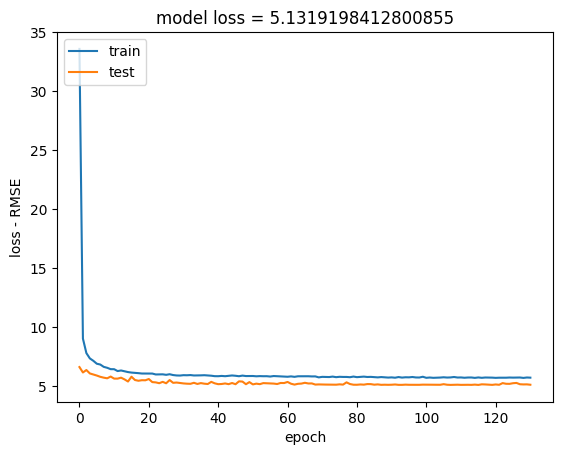


Tested architectures: 50
Best val_loss: 26.143173
Best config: {'static_layers': [128, 256], 'merge_layers': []} Params: 55425


In [127]:
# -------------------------------------------------------------
# --- Global reproducibility ---
# -------------------------------------------------------------
BASE_SEED = 228
os.environ["PYTHONHASHSEED"] = str(BASE_SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
tf.random.set_seed(BASE_SEED)

# -------------------------------------------------------------
# --- Fixed hyperparameters ---
# -------------------------------------------------------------
ACTIV       = "relu"
DROPOUT     = 0.15
BATCH_SIZE  = 128
EPOCHS      = 200
PATIENCE    = 15

# -------------------------------------------------------------
# --- Search space (architecture only)
# -------------------------------------------------------------
STATIC_UNITS  = [32, 64, 128, 256]
STATIC_DEPTH  = [1, 2, 3]
MERGE_UNITS   = [32, 64, 128, 256]
MERGE_DEPTH   = [0, 1, 2]
N_TRIALS = 50

rng = np.random.RandomState(BASE_SEED)

# -------------------------------------------------------------
# --- Helper: sample arbitrary layer structure ---
# -------------------------------------------------------------
def sample_layers(units_pool, depth, rng):
    """Generates e.g. [256, 64, 128] or [32, 32] — freely sampled."""
    return [int(rng.choice(units_pool)) for _ in range(depth)]

# -------------------------------------------------------------
# --- Sample a random architecture ---
# -------------------------------------------------------------
def sample_architecture(rng):
    s_depth = int(rng.choice(STATIC_DEPTH))
    static_layers = sample_layers(STATIC_UNITS, s_depth, rng)

    m_depth = int(rng.choice(MERGE_DEPTH))
    merge_layers = sample_layers(MERGE_UNITS, m_depth, rng) if m_depth > 0 else []

    return {
        "static_layers": static_layers,
        "merge_layers": merge_layers
    }

# -------------------------------------------------------------
# --- Random search ---
# -------------------------------------------------------------
results = []
best = {"val_loss": float("inf"), "cfg": None, "weights": None, "n_params": None}

for trial in range(N_TRIALS):
    cfg = sample_architecture(rng)

    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.8,
        patience=6,
        min_lr=1e-5,
        verbose=0
    )

    callbacks_train = [plot_losses, early_stop, reduce_lr]  # if plot_losses exists

    model = create_supervised(
        input_shape_static=input_shape_static,
        output_shape=1,
        static_layers=cfg["static_layers"],
        merge_layers=cfg["merge_layers"],
        activ=ACTIV,
        dropout=DROPOUT,
        seed=BASE_SEED
    )

    hist = model.fit(
        x=X_static_train,
        y=y_train,
        validation_data=(X_static_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,
        verbose=0,
        callbacks=callbacks_train
    )

    val_loss = float(min(hist.history["val_loss"]))
    n_params = model.count_params()
    results.append((val_loss, n_params, cfg, model.get_weights()))

    if val_loss < best["val_loss"]:
        best.update({
            "val_loss": val_loss,
            "cfg": cfg,
            "weights": model.get_weights(),
            "n_params": n_params
        })

print(f"\nTested architectures: {len(results)}")
print("Best val_loss:", round(best["val_loss"], 6))
print("Best config:", best["cfg"], "Params:", best["n_params"])

# -------------------------------------------------------------
# --- Final evaluation on test set ---
# -------------------------------------------------------------
supervised = create_supervised(
    input_shape_static=input_shape_static,
    output_shape=1,
    static_layers=best["cfg"]["static_layers"],
    merge_layers=best["cfg"]["merge_layers"],
    activ=ACTIV,
    dropout=DROPOUT,
    seed=BASE_SEED
)
supervised.set_weights(best["weights"])

In [128]:
supervised.summary()

Model: "FF_custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_static (InputLayer)       │ (None, 172)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_415 (Dense)               │ (None, 128)            │        22,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_416 (Dense)               │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_417 (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,425 (216.50 KB)

 Trainable params: 55,425 (216.50 KB)

 Non-trainable params: 0 (0.00 B)

#### Model initialization with input shape and architecture parameters

#### Evaluation of the Model

In [129]:
# --- Compute RMSE between true and predicted values ---
def compute_cost(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_pred - y_true)**2))
    return rmse

In [130]:
def plot_result(y_true, y_pred, band=None):
    """
    Plot actual vs. predicted with y=x and an optional ±band, 
    print MAE/RMSE/R², and return a metrics DataFrame.

    Args:
        y_true, y_pred: array-like of shape (n_samples,)
        band: float or None — half-width (in seconds) around y=x

    Returns:
        pd.DataFrame with columns ["Metric", "Value"]
    """
    # Align arrays and drop NaNs
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    # Residuals and metrics
    residuals = y_true - y_pred
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    metrics_df = pd.DataFrame({
        "Metric": ["Mean Absolute Error (MAE) [s]",
                   "Root Mean Square Error (RMSE) [s]",
                   "R² Score"],
        "Value": [round(mae, 2), round(rmse, 2), round(r2, 3)]
    })
    print(metrics_df.to_string(index=False))

    # Scatter: actual vs predicted
    plt.figure(figsize=(9, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, label="Samples")

    xy_min = min(y_true.min(), y_pred.min())
    xy_max = max(y_true.max(), y_pred.max())

    # y = x reference
    plt.plot([xy_min, xy_max], [xy_min, xy_max], 'r--', label="y = x")

    # Optional ±band around y = x
    if band is not None and band > 0:
        xs = np.linspace(xy_min, xy_max, 200)
        plt.plot(xs, xs + band, 'r:', linewidth=1)
        plt.plot(xs, xs - band, 'r:', linewidth=1)
        plt.fill_between(xs, xs - band, xs + band, alpha=0.08)

    plt.xlabel("Actual AROT [s]")
    plt.ylabel("Predicted AROT [s]")
    plt.title("Actual vs Predicted AROT")
    plt.xlim(xy_min, xy_max)
    plt.ylim(xy_min, xy_max)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [131]:
def plot_result_plotly(y_true, y_pred, show_cdf=True):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    residuals = y_true - y_pred
    abs_errors = np.abs(residuals)

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    metrics_df = pd.DataFrame({
        "Metric": [
            "Mean Absolute Error (MAE) [s]",
            "Root Mean Square Error (RMSE) [s]",
            "R² Score"
        ],
        "Value": [round(mae, 2), round(rmse, 2), round(r2, 2)]
    })
    print(metrics_df.to_string(index=False))

    output_dir = 'Plots'
    os.makedirs(output_dir, exist_ok=True)

    comparison_df = pd.DataFrame({
        "Actual ROT": y_true,
        "Residual (signed)": residuals
    })

    # 1) Residual scatter plot
    scatter = go.Scatter(
        x=comparison_df['Actual ROT'],
        y=comparison_df['Residual (signed)'],
        mode='markers',
        marker=dict(size=10, color='blue', line=dict(width=1, color='black'), opacity=0.6),
        name='Residuals'
    )
    zero_line = go.Scatter(
        x=[comparison_df['Actual ROT'].min(), comparison_df['Actual ROT'].max()],
        y=[0, 0],
        mode='lines',
        line=dict(color='red', dash='dash'),
        name='Zero Line'
    )

    fig_scatter = go.Figure(data=[scatter, zero_line])
    fig_scatter.update_layout(
        width=800,
        height=500,
        xaxis=dict(title='Actual AROT [s]', title_font=dict(size=18), tickfont=dict(size=14)),
        yaxis=dict(title='Residuals [s]', title_font=dict(size=18), tickfont=dict(size=14)),
        showlegend=True,
        legend=dict(x=0.01, y=0.99),
        margin=dict(l=40, r=40, t=20, b=40)
    )
    fig_scatter.write_image(os.path.join(output_dir, 'residual_scatter_plot.png'), scale=5)
    fig_scatter.show()

    # 2) Absolute-error CDF (optional)
    if show_cdf:
        sorted_errors = np.sort(abs_errors)
        cumulative_probs = np.linspace(0, 1, len(sorted_errors))

        median_error = np.quantile(abs_errors, 0.5)
        q90_error = np.quantile(abs_errors, 0.9)

        cdf_plot = go.Scatter(
            x=sorted_errors,
            y=cumulative_probs,
            mode='lines',
            line=dict(color='blue', width=2),
            showlegend=False
        )

        median_line = go.Scatter(
            x=[median_error, median_error],
            y=[0, 0.5],
            mode='lines',
            line=dict(color='green', dash='dash', width=2),
            showlegend=False
        )
        q90_line = go.Scatter(
            x=[q90_error, q90_error],
            y=[0, 0.9],
            mode='lines',
            line=dict(color='red', dash='dash', width=2),
            showlegend=False
        )

        median_hline = go.Scatter(
            x=[0, median_error],
            y=[0.5, 0.5],
            mode='lines',
            line=dict(color='green', dash='dot', width=2),
            showlegend=False
        )
        q90_hline = go.Scatter(
            x=[0, q90_error],
            y=[0.9, 0.9],
            mode='lines',
            line=dict(color='red', dash='dot', width=2),
            showlegend=False
        )

        median_text = go.Scatter(
            x=[median_error + 2.2],
            y=[0.2],
            mode='text',
            text=[f'{median_error:.2f}s'],
            textfont=dict(size=17),
            showlegend=False
        )
        median_label = go.Scatter(
            x=[1.8],
            y=[0.53],
            mode='text',
            text=['Median'],
            textfont=dict(size=17),
            showlegend=False
        )
        q90_text = go.Scatter(
            x=[q90_error + 2.2],
            y=[0.2],
            mode='text',
            text=[f'{q90_error:.2f}s'],
            textfont=dict(size=17),
            showlegend=False
        )
        q90_label = go.Scatter(
            x=[4],
            y=[0.93],
            mode='text',
            text=['90th Quantile'],
            textfont=dict(size=17),
            showlegend=False
        )

        layout_cdf = go.Layout(
            xaxis=dict(title='Absolute Error [s]', title_font=dict(size=20), tickfont=dict(size=16), dtick=2, range=[0, sorted_errors.max()]),
            yaxis=dict(title='Cumulative Probability', title_font=dict(size=20), tickfont=dict(size=16)),
            margin=dict(l=10, r=10, t=10, b=10),
            width=1000,
            height=500,
            showlegend=False
        )

        fig_cdf = go.Figure(data=[
            cdf_plot,
            median_line, q90_line,
            median_hline, q90_hline,
            median_text, median_label,
            q90_text, q90_label
        ], layout=layout_cdf)

        fig_cdf.write_image(os.path.join(output_dir, 'absolute_error_cdf.pdf'), scale=5)
        fig_cdf.show()


#### Evaluation of the final trained Model on the Training Data

606/606 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Train RMSE = 5.1
                           Metric  Value
    Mean Absolute Error (MAE) [s]  4.000
Root Mean Square Error (RMSE) [s]  5.140
                         R² Score  0.311


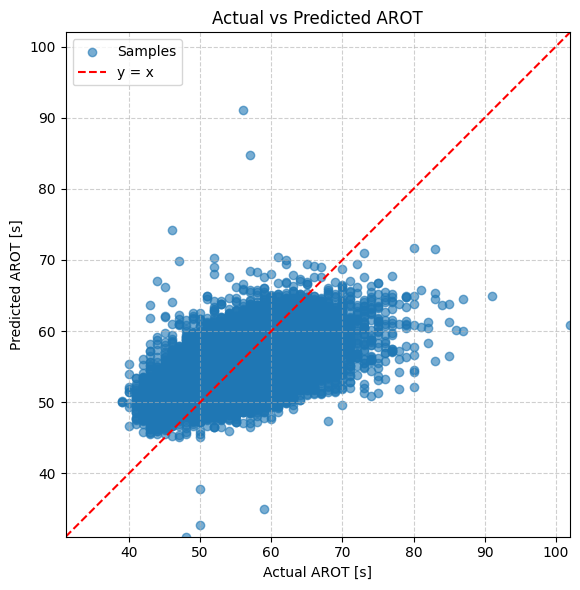

In [132]:
# Predict on training data
y_hat_train = supervised.predict(X_static_train)
y_hat_train = np.ravel(y_hat_train)

# Compute RMSE manually (for older sklearn versions)
rmse_train = np.sqrt(mean_squared_error(y_train, y_hat_train))

# Report Results
print("\nTrain RMSE =", np.round(rmse_train, 1))

# Plot residual analysis
plot_result(y_true=y_train, y_pred=y_hat_train)


#### Evaluation of final Model on the Validation Data

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Validation RMSE = 5.11
                           Metric  Value
    Mean Absolute Error (MAE) [s]  4.000
Root Mean Square Error (RMSE) [s]  5.110
                         R² Score  0.314


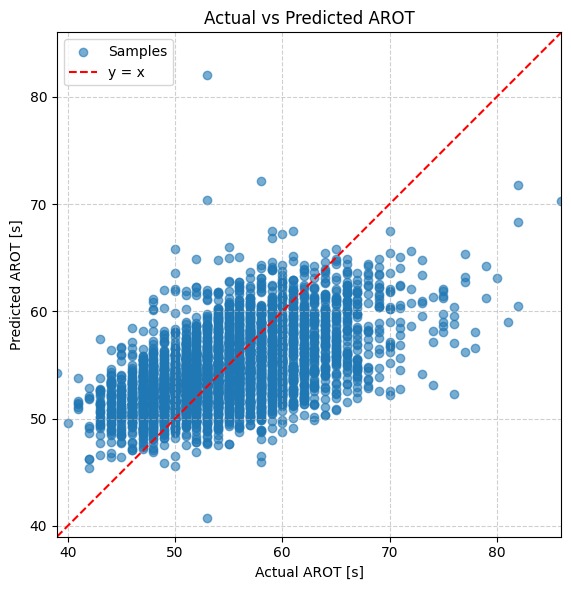

In [133]:
# Model prediction
y_hat_val = supervised.predict(X_static_val)
y_hat_val = np.ravel(y_hat_val)

# Compute RMSE (Root Mean Squared Error)
rmse_val = np.sqrt(mean_squared_error(y_val, y_hat_val))

# Report RMSE
print("Validation RMSE =", round(rmse_val, 2))

# Plot residual analysis (residual = true - predicted)
plot_result(y_true=y_val, y_pred=y_hat_val)


#### Evaluation of final Model on the Test Data

In [134]:
# Model prediction
y_hat_test = supervised.predict(X_static_test)
y_hat_test = np.ravel(y_hat_test)

# Compute RMSE (Root Mean Squared Error)
rmse_test = np.sqrt(mean_squared_error(y_test, y_hat_test))

# Report RMSE
print("Test RMSE =", round(rmse_test, 2))

# Plot residual analysis (residual = true - predicted)
plot_result_plotly(y_true=y_test, y_pred=y_hat_test)

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test RMSE = 5.1
                           Metric  Value
    Mean Absolute Error (MAE) [s]    4.0
Root Mean Square Error (RMSE) [s]    5.1
                         R² Score    0.3
